# Análise exploratória inicial

In [61]:
#Carregamento da base
import pandas as pd

dataset = pd.read_csv('cat_breeds_dirty.csv', sep = ';')

In [ ]:
#Verificando o tamanho do dataset
dataset.shape

(1103, 17)

In [58]:
#Fazendo a leitura das primeiras linhas do dataset
dataset.head()

,Breed,Age_in_years,Age_in_months,Gender,Neutered_or_spayed,Body_length,Weight,Fur_colour_dominant,Fur_pattern,Eye_colour,Allowed_outdoor,Preferred_food,Owner_play_time_minutes,Sleep_time_hours,Country,Latitude,Longitude
0,Angora,0.25,3.0,female,False,19.0,2.0,white,solid,blue,FALSE,wet,46.0,16.0,France,43.296482,5.369780
1,Angora,0.33,4.0,male,False,19.0,2.5,white,solid,blue,FALSE,wet,48.0,16.0,France,43.611660,3.877710
2,Angora,0.50,NaN,NaN,False,20.0,2.8,what does it mean dominant?,solid,green,I never allow my kitty outside!!!!!,wet,41.0,11.0,France,44.837789,-0.579180
3,Ankora,0.50,NaN,NaN,False,21.0,3.0,white,dirty,blue,FALSE,wet,24.0,8.0,France,43.611660,3.877710
4,Angora,0.50,NaN,NaN,NaN,21.0,3.0,red/cream,tabby,green,FALSE,wet,51.0,10.0,france,48.864716,2.349014


In [59]:
#Verificação de valores nulos
dataset.isnull().sum()

Breed                      112
Age_in_years                31
Age_in_months               37
Gender                      67
Neutered_or_spayed          53
Body_length                 26
Weight                      26
Fur_colour_dominant         13
Fur_pattern                 48
Eye_colour                  39
Allowed_outdoor             43
Preferred_food              21
Owner_play_time_minutes     21
Sleep_time_hours            41
Country                     75
Latitude                    61
Longitude                   61
dtype: int64

In [76]:
dataset.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1098     True
1099     True
1100     True
1101     True
1102     True
Length: 1103, dtype: bool

In [77]:
dataset.duplicated().sum()

np.int64(32)

In [60]:
dataset.describe()

,Age_in_years,Age_in_months,Body_length,Weight,Owner_play_time_minutes,Sleep_time_hours,Latitude,Longitude
count,1072.000000,1066.000000,1077.000000,1077.000000,1082.000000,1062.000000,1042.000000,1042.000000
mean,4.460752,53.778612,43.903435,5.740901,23.176525,15.898305,44.550898,-59.517623
std,3.262166,39.355581,16.240466,9.853438,10.815298,2.656775,4.931844,46.259368
min,-7.666667,-92.000000,10.000000,0.500000,0.000000,8.000000,37.774930,-123.116226
25%,2.330000,28.000000,35.000000,3.900000,15.000000,14.000000,40.714270,-77.036370
50%,4.750000,57.000000,41.000000,5.000000,23.000000,16.000000,43.296482,-74.005970
75%,6.920000,84.000000,51.000000,7.000000,31.000000,18.000000,48.864716,-1.890401
max,11.250000,135.000000,102.000000,320.000000,60.000000,32.000000,53.800755,13.404954


# Limpeza dos dados

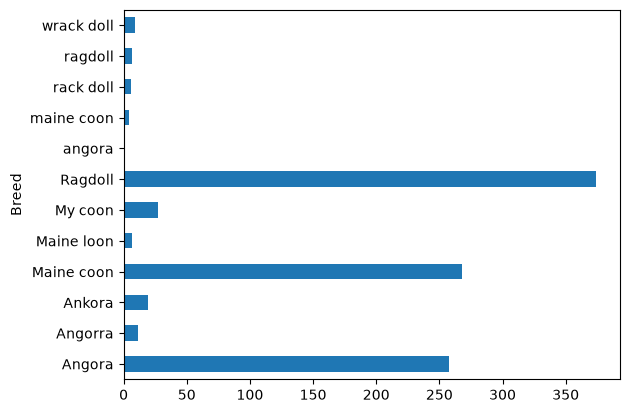

In [45]:
#Analisando variações de valores na coluna Breed
import matplotlib as plot
dataset.groupby('Breed')['Breed'].count().plot.barh();

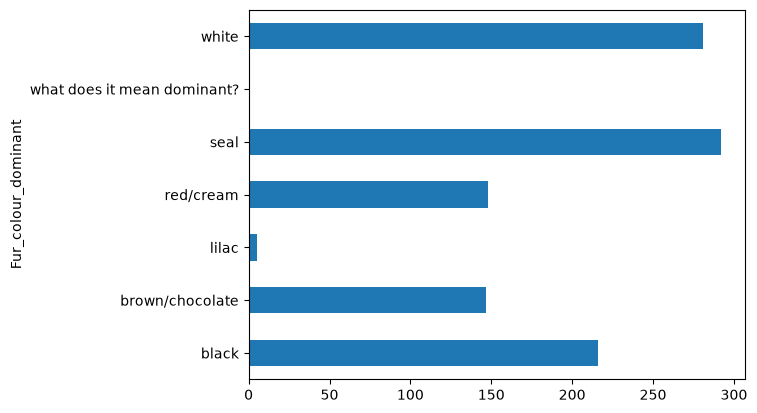

In [ ]:
#Conferindo valores de Gender e Fur_colou_dominant
#dataset.groupby('Gender')['Gender'].count().plot.barh(); -> Conferindo valores de Gender
dataset.groupby('Fur_colour_dominant')['Fur_colour_dominant'].count().plot.barh();

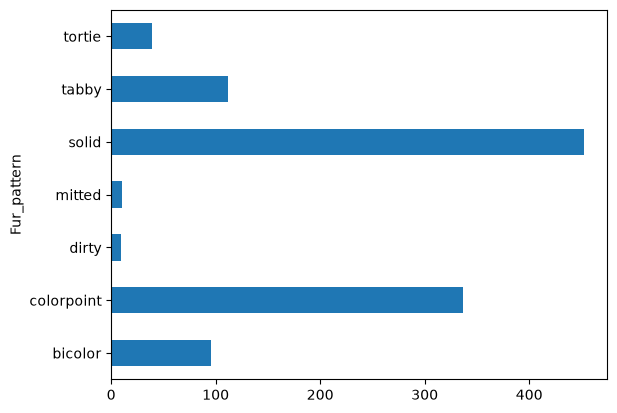

In [ ]:
#Conferindo valores de Fur_pattern
dataset.groupby('Fur_pattern')['Fur_pattern'].count().plot.barh();

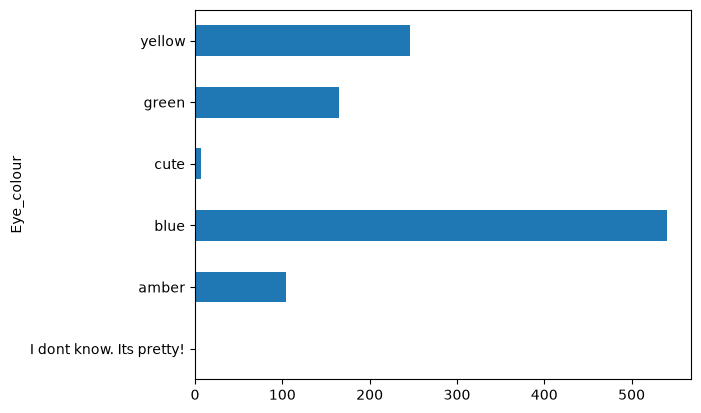

In [ ]:
#Conferindo valores de Eye_colour
dataset.groupby('Eye_colour')['Eye_colour'].count().plot.barh();

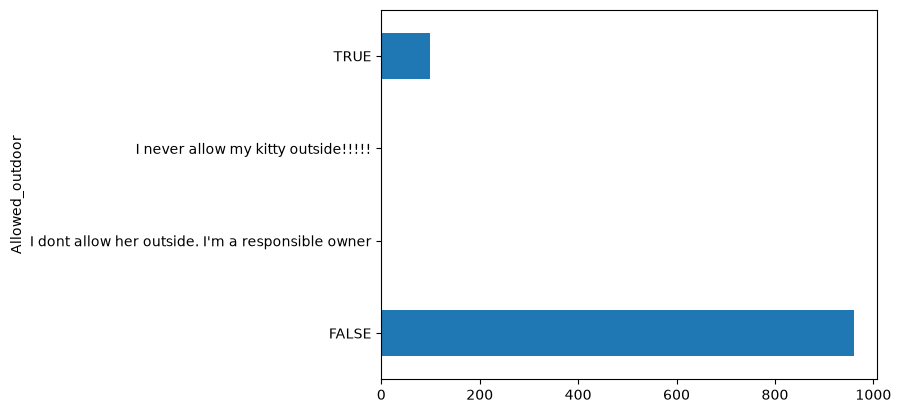

In [ ]:
#Conferindo valores de Allowed_outdoor
dataset.groupby('Allowed_outdoor')['Allowed_outdoor'].count().plot.barh();

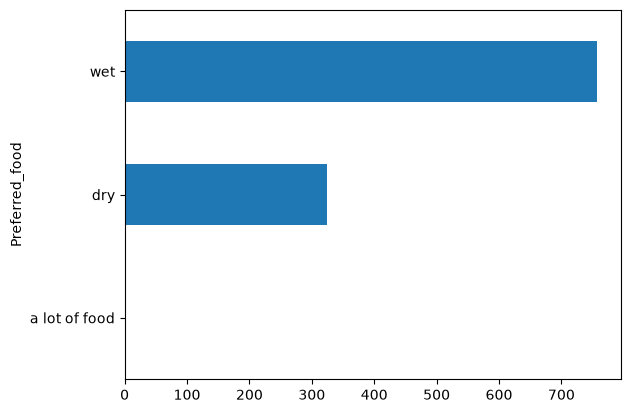

In [ ]:
#Conferindo valores de Preferred_food
dataset.groupby('Preferred_food')['Preferred_food'].count().plot.barh();

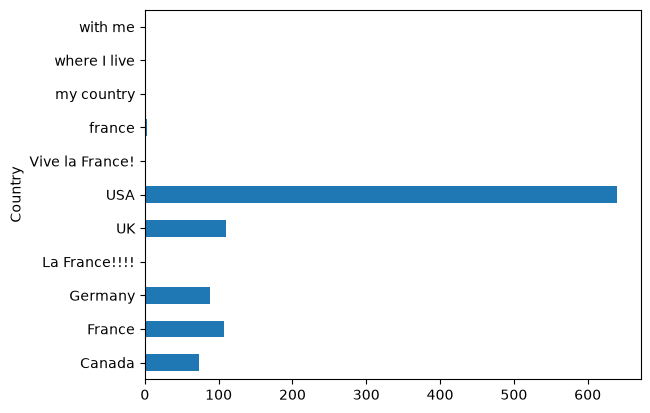

In [ ]:
#Conferindo valores de Country
dataset.groupby('Country')['Country'].count().plot.barh();

In [ ]:
#Padronizando todos os valores errados de algumas colunas, padronizando nomes e colocando como nulo valores que não fazem sentido para a análise
dataset['Breed'] = dataset['Breed'].replace('Ankora', 'Angora')
dataset['Breed'] = dataset['Breed'].replace('Angorra', 'Angora')
dataset['Breed'] = dataset['Breed'].replace('angora', 'Angora')

dataset['Breed'] = dataset['Breed'].replace('My coon', 'Maine coon')
dataset['Breed'] = dataset['Breed'].replace('maine coon', 'Maine coon')
dataset['Breed'] = dataset['Breed'].replace('Maine loon', 'Maine coon')

dataset['Breed'] = dataset['Breed'].replace('rack doll', 'Ragdoll')
dataset['Breed'] = dataset['Breed'].replace('wrack doll', 'Ragdoll')
dataset['Breed'] = dataset['Breed'].replace('ragdoll', 'Ragdoll')

dataset['Fur_colour_dominant'] = dataset['Fur_colour_dominant'].replace('what does it mean dominant?', 'NaN')
dataset['Fur_pattern'] = dataset['Fur_pattern'].replace('dirty', 'NaN')

dataset['Eye_colour'] = dataset['Eye_colour'].replace('cute', 'NaN')
dataset['Eye_colour'] = dataset['Eye_colour'].replace('I dont know. Its pretty!', 'NaN')

dataset['Allowed_outdoor'] = dataset['Allowed_outdoor'].replace('I never allow my kitty outside!!!!!', 'FALSE')
dataset['Allowed_outdoor'] = dataset['Allowed_outdoor'].replace("I dont allow her outside. I'm a responsible owner", 'FALSE')

dataset['Preferred_food'] = dataset['Preferred_food'].replace('a lot of food', 'NaN')

dataset['Country'] = dataset['Country'].replace('La France!!!!', 'France')
dataset['Country'] = dataset['Country'].replace('Vive la France!', 'France')
dataset['Country'] = dataset['Country'].replace('my country', 'NaN')
dataset['Country'] = dataset['Country'].replace('with me', 'NaN')
dataset['Country'] = dataset['Country'].replace('where I live', 'NaN')
dataset['Country'] = dataset['Country'].replace('france', 'France')
dataset['Country'] = dataset['Country'].replace('Nan', 'NaN')

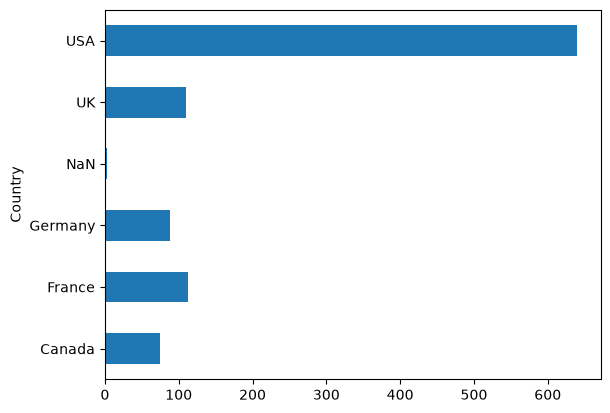

In [74]:
#Conferindo padronização dos valores
#dataset.groupby('Breed')['Breed'].count().plot.barh();
#dataset.groupby('Fur_colour_dominant')['Fur_colour_dominant'].count().plot.barh();
#dataset.groupby('Fur_pattern')['Fur_pattern'].count().plot.barh();
#dataset.groupby('Eye_colour')['Eye_colour'].count().plot.barh();
#dataset.groupby('Allowed_outdoor')['Allowed_outdoor'].count().plot.barh();
#dataset.groupby('Allowed_outdoor')['Allowed_outdoor'].count().plot.barh();
#dataset.groupby('Preferred_food')['Preferred_food'].count().plot.barh();
dataset.groupby('Country')['Country'].count().plot.barh();



In [ ]:
#Removendo o limite máximo de linhas exibidas
pd.set_option('display.max_rows', None)

#Mostrando todas as linhas duplicadas
dataset[dataset.duplicated()]

,Breed,Age_in_years,Age_in_months,Gender,Neutered_or_spayed,Body_length,Weight,Fur_colour_dominant,Fur_pattern,Eye_colour,Allowed_outdoor,Preferred_food,Owner_play_time_minutes,Sleep_time_hours,Country,Latitude,Longitude
1071,Angora,2.250000,27.0,male,True,25.0,3.1,white,solid,amber,FALSE,wet,39.0,16.0,France,47.218371,-1.553621
1072,Angora,2.250000,27.0,male,True,38.0,5.3,white,solid,amber,FALSE,wet,39.0,14.0,France,48.864716,2.349014
1073,Angora,2.330000,28.0,female,False,36.0,4.0,red/cream,solid,blue,FALSE,dry,19.0,14.0,France,47.218371,-1.553621
1074,Angora,2.330000,28.0,female,False,36.0,2.4,white,NaN,blue,FALSE,wet,19.0,16.0,France,45.763420,4.834277
1075,Angora,2.330000,28.0,male,True,39.0,3.9,white,solid,blue,FALSE,wet,34.0,14.0,France,45.763420,4.834277
1076,Angora,2.670000,32.0,female,True,38.0,3.9,red/cream,solid,blue,FALSE,wet,37.0,14.0,France,44.837789,-0.579180
1077,Angora,2.670000,32.0,male,False,40.0,4.0,black,solid,blue,FALSE,dry,30.0,14.0,France,43.296482,5.369780
1078,Angora,2.670000,32.0,female,True,34.0,3.9,black,solid,green,TRUE,dry,21.0,14.0,France,45.763420,4.834277
1079,Angora,2.920000,35.0,female,True,34.0,4.1,white,solid,green,TRUE,wet,28.0,14.0,France,43.296482,5.369780
1080,Angora,2.920000,35.0,female,True,32.0,2.5,white,solid,amber,FALSE,wet,33.0,14.0,France,48.864716,2.349014


In [87]:
#Padronizando valores negativos de algumas colunas, como idade em anos e meses
cols = ['Age_in_years', 'Age_in_months']
dataset[cols] = dataset[cols].abs()


In [ ]:
#Padronizando valores de idade em anos para duas casas decimais
dataset['Age_in_years'] = dataset['Age_in_years'].round(2)

In [99]:
#Corrigindo valor discrepante na coluna Weight
dataset['Weight'] = dataset['Weight'].replace(320, 3.20)

In [ ]:
#Conferindo as correções
dataset.describe().round(2)

,Age_in_years,Age_in_months,Body_length,Weight,Owner_play_time_minutes,Sleep_time_hours,Latitude,Longitude
count,1072.00,1066.00,1077.00,1077.00,1082.00,1062.00,1042.00,1042.00
mean,4.82,58.10,43.90,5.45,23.18,15.90,44.55,-59.52
std,2.71,32.64,16.24,2.29,10.82,2.66,4.93,46.26
min,0.08,1.00,10.00,0.50,0.00,8.00,37.77,-123.12
25%,2.67,32.00,35.00,3.90,15.00,14.00,40.71,-77.04
50%,4.83,58.00,41.00,5.00,23.00,16.00,43.30,-74.01
75%,7.00,84.00,51.00,7.00,31.00,18.00,48.86,-1.89
max,11.25,135.00,102.00,12.10,60.00,32.00,53.80,13.40


In [ ]:
#Removendo espaços em branco dos nomes das colunas
dataset.columns = dataset.columns.str.strip()

In [125]:
#Alterando variações de valores 'nulos' para np.nan
dataset['Fur_colour_dominant'] = dataset['Fur_colour_dominant'].replace(['nan', 'NaN', 'null', '', ' '], np.nan)
dataset['Fur_pattern'] = dataset['Fur_pattern'].replace(['nan', 'NaN', 'null', '', ' '], np.nan)
dataset['Eye_colour'] = dataset['Eye_colour'].replace(['nan', 'NaN', 'null', '', ' '], np.nan)
dataset['Preferred_food'] = dataset['Preferred_food'].replace(['nan', 'NaN', 'null', '', ' '], np.nan)
dataset['Country'] = dataset['Country'].replace(['nan', 'NaN', 'null', '', ' '], np.nan)

In [126]:
#Verificando valores de moda para as colunas categóricas

print(dataset['Breed'].mode())
print(dataset['Gender'].mode())
print(dataset['Neutered_or_spayed'].mode())
print(dataset['Fur_colour_dominant'].mode())
print(dataset['Fur_pattern'].mode())
print(dataset['Eye_colour'].mode())
print(dataset['Allowed_outdoor'].mode())
print(dataset['Preferred_food'].mode())
print(dataset['Country'].mode())



0    Ragdoll
Name: Breed, dtype: str
0    male
Name: Gender, dtype: str
0    True
Name: Neutered_or_spayed, dtype: object
0    seal
Name: Fur_colour_dominant, dtype: str
0    solid
Name: Fur_pattern, dtype: str
0    blue
Name: Eye_colour, dtype: str
0    FALSE
Name: Allowed_outdoor, dtype: str
0    wet
Name: Preferred_food, dtype: str
0    USA
Name: Country, dtype: str


In [127]:
#Preenchendo valores nulos com a moda das colunas categóricas

dataset['Breed'] = dataset['Breed'].fillna(dataset['Breed'].mode()[0])
dataset['Gender'] = dataset['Gender'].fillna(dataset['Gender'].mode()[0])
dataset['Neutered_or_spayed'] = dataset['Neutered_or_spayed'].fillna(dataset['Neutered_or_spayed'].mode()[0])   
dataset['Fur_colour_dominant'] = dataset['Fur_colour_dominant'].fillna(dataset['Fur_colour_dominant'].mode()[0])
dataset['Fur_pattern'] = dataset['Fur_pattern'].fillna(dataset['Fur_pattern'].mode()[0])
dataset['Eye_colour'] = dataset['Eye_colour'].fillna(dataset['Eye_colour'].mode()[0])
dataset['Allowed_outdoor'] = dataset['Allowed_outdoor'].fillna(dataset['Allowed_outdoor'].mode()[0])
dataset['Preferred_food'] = dataset['Preferred_food'].fillna(dataset['Preferred_food'].mode()[0])
dataset['Country'] = dataset['Country'].fillna(dataset['Country'].mode()[0])


In [128]:
#Preenchendo valores nulos com a mediana das colunas numéricas

dataset['Age_in_years'] = dataset['Age_in_years'].fillna(dataset['Age_in_years'].median())
dataset['Age_in_months'] = dataset['Age_in_months'].fillna(dataset['Age_in_months'].median())
dataset['Body_length'] = dataset['Body_length'].fillna(dataset['Body_length'].median())   
dataset['Weight'] = dataset['Weight'].fillna(dataset['Weight'].median())
dataset['Owner_play_time_minutes'] = dataset['Owner_play_time_minutes'].fillna(dataset['Owner_play_time_minutes'].median())
dataset['Sleep_time_hours'] = dataset['Sleep_time_hours'].fillna(dataset['Sleep_time_hours'].median())
dataset['Latitude'] = dataset['Latitude'].fillna(dataset['Latitude'].median())
dataset['Longitude'] = dataset['Longitude'].fillna(dataset['Longitude'].median())

In [129]:
dataset.isnull().sum()

Breed                      0
Age_in_years               0
Age_in_months              0
Gender                     0
Neutered_or_spayed         0
Body_length                0
Weight                     0
Fur_colour_dominant        0
Fur_pattern                0
Eye_colour                 0
Allowed_outdoor            0
Preferred_food             0
Owner_play_time_minutes    0
Sleep_time_hours           0
Country                    0
Latitude                   0
Longitude                  0
dtype: int64

In [ ]:
#Conferindo os dados após a limpeza e padronização
dataset.head(50)

,Breed,Age_in_years,Age_in_months,Gender,Neutered_or_spayed,Body_length,Weight,Fur_colour_dominant,Fur_pattern,Eye_colour,Allowed_outdoor,Preferred_food,Owner_play_time_minutes,Sleep_time_hours,Country,Latitude,Longitude
0,Angora,0.25,3.0,female,False,19.0,2.0,white,solid,blue,FALSE,wet,46.0,16.0,France,43.296482,5.369780
1,Angora,0.33,4.0,male,False,19.0,2.5,white,solid,blue,FALSE,wet,48.0,16.0,France,43.611660,3.877710
2,Angora,0.50,58.0,male,False,20.0,2.8,seal,solid,green,FALSE,wet,41.0,11.0,France,44.837789,-0.579180
3,Angora,0.50,58.0,male,False,21.0,3.0,white,solid,blue,FALSE,wet,24.0,8.0,France,43.611660,3.877710
4,Angora,0.50,58.0,male,True,21.0,3.0,red/cream,tabby,green,FALSE,wet,51.0,10.0,France,48.864716,2.349014
5,Ragdoll,0.50,6.0,female,False,21.0,3.0,white,solid,amber,FALSE,wet,30.0,28.0,France,43.611660,3.877710
6,Angora,0.58,58.0,male,True,22.0,3.0,white,solid,amber,FALSE,wet,47.0,9.0,France,47.218371,-1.553621
7,Angora,4.83,7.0,male,True,23.0,3.0,red/cream,solid,blue,FALSE,wet,55.0,11.0,France,47.218371,-1.553621
8,Angora,4.83,7.0,female,True,25.0,3.0,black,solid,blue,FALSE,wet,20.0,12.0,France,43.296482,5.369780
9,Angora,4.83,8.0,female,True,25.0,3.2,white,solid,blue,FALSE,wet,33.0,17.0,France,44.837789,-0.579180


# Visualizações

In [ ]:
#Configuração de estilo para os gráficos
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

PALETTE = {
    'bg': '#1a1a2e',
    'panel': '#16213e',
    'text': '#eaeaea',
    'muted': '#a0a0b0',
    'cats': ['#e94560','#f5a623','#7ed6a7','#6c9bcf','#c084fc','#fb923c'],
    'breeds': {'Angora': '#e94560', 'Ragdoll': '#f5a623', 'Maine coon': '#7ed6a7'},
    'gender': {'female': '#FF69B4', 'male': '#6c9bcf'},
}

def style_ax(ax, title, xlabel='', ylabel=''):
    ax.set_facecolor(PALETTE['panel'])
    ax.set_title(title, color=PALETTE['text'], fontsize=13, fontweight='bold', pad=14)
    ax.set_xlabel(xlabel, color=PALETTE['muted'], fontsize=10)
    ax.set_ylabel(ylabel, color=PALETTE['muted'], fontsize=10)
    ax.tick_params(colors=PALETTE['muted'], labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2a4a')
    ax.grid(axis='y', color='#2a2a4a', linewidth=0.6, linestyle='--')

breeds = ['Angora', 'Ragdoll', 'Maine coon']



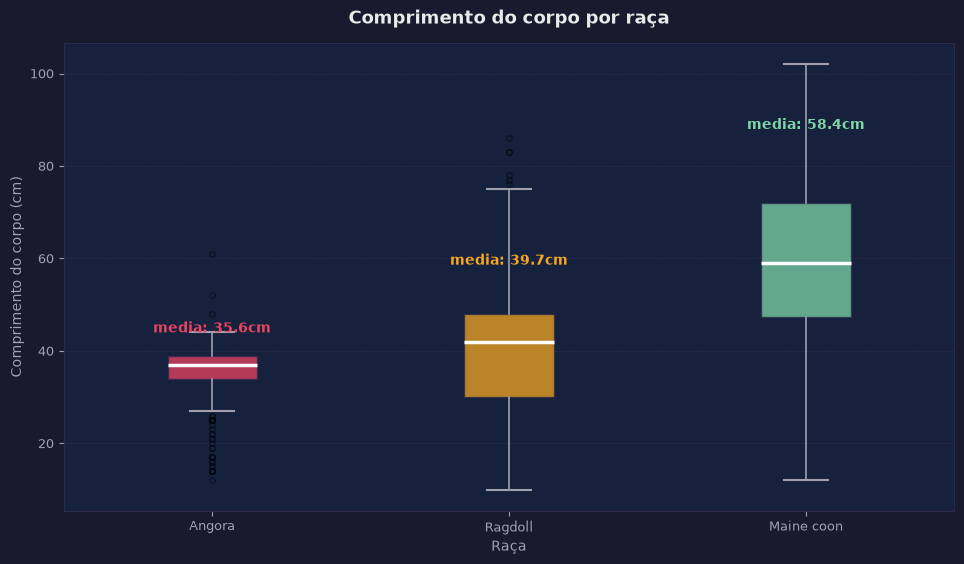

In [154]:
#Analisando comprimento do corpo por raça
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(PALETTE['bg'])

data_bp = [dataset[dataset['Breed']==b]['Body_length'].values for b in breeds]
bp = ax.boxplot(data_bp, patch_artist=True,
                medianprops=dict(color='white', linewidth=2.5),
                whiskerprops=dict(color=PALETTE['muted'], linewidth=1.2),
                capprops=dict(color=PALETTE['muted'], linewidth=1.5),
                flierprops=dict(marker='o', color=PALETTE['muted'], alpha=0.4, markersize=4))

for patch, color in zip(bp['boxes'], PALETTE['cats']):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
    patch.set_edgecolor('#2a2a4a')

# Média anotada acima do bigode superior
for i, b in enumerate(breeds):
    media = dataset[dataset['Breed']==b]['Body_length'].mean()
    maximo = dataset[dataset['Breed']==b]['Body_length'].quantile(0.95)
    ax.text(i+1, maximo + 3, f'media: {media:.1f}cm',
            ha='center', color=PALETTE['cats'][i], fontsize=10, fontweight='bold')

ax.set_xticks(range(1, len(breeds)+1))
ax.set_xticklabels(breeds, color=PALETTE['muted'], fontsize=11)
style_ax(ax, 'Comprimento do corpo por raça', 'Raça', 'Comprimento do corpo (cm)')

plt.tight_layout(pad=2)
plt.show()

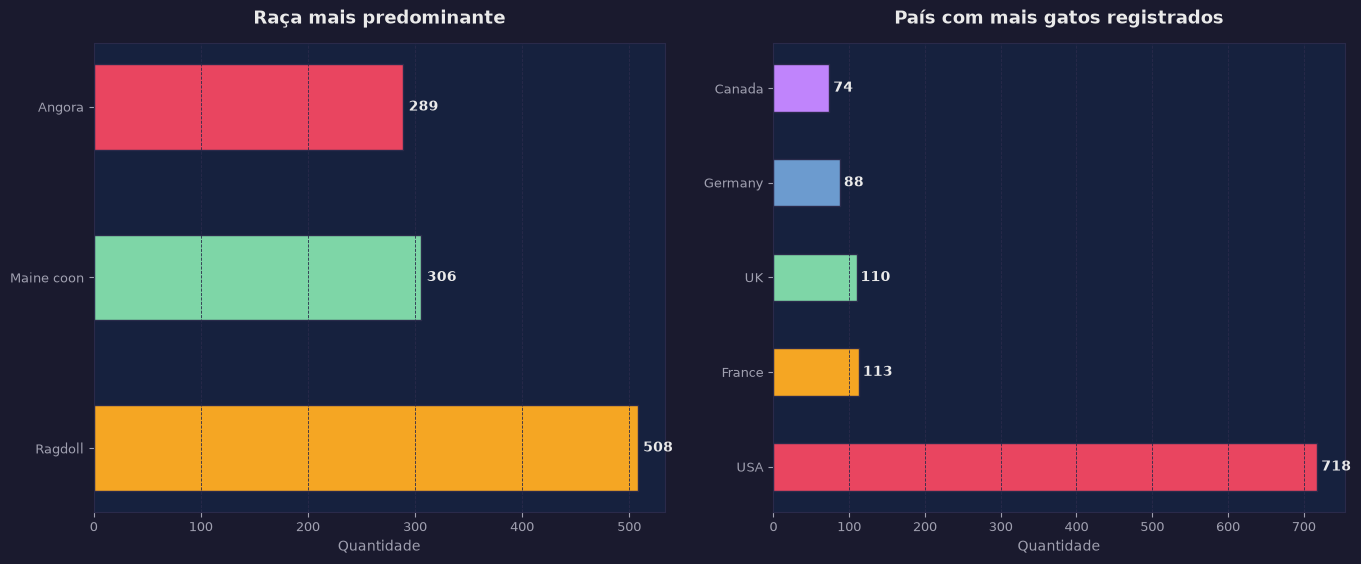

In [156]:
#Raça mais predominante e país com mais gatos registrados
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(PALETTE['bg'])

contagem_breed = dataset['Breed'].value_counts()
bars = axes[0].barh(contagem_breed.index, contagem_breed.values,
                    color=[PALETTE['breeds'][b] for b in contagem_breed.index],
                    edgecolor='#2a2a4a', height=0.5)
for bar, v in zip(bars, contagem_breed.values):
    axes[0].text(v+5, bar.get_y()+bar.get_height()/2, str(v),
                 va='center', color=PALETTE['text'], fontsize=10, fontweight='bold')
style_ax(axes[0], 'Raça mais predominante', 'Quantidade', '')
axes[0].set_facecolor(PALETTE['panel'])
axes[0].grid(axis='x', color='#2a2a4a', linewidth=0.6, linestyle='--')
axes[0].grid(axis='y', color='none')

contagem_country = dataset['Country'].value_counts()
bars2 = axes[1].barh(contagem_country.index, contagem_country.values,
                     color=PALETTE['cats'][:len(contagem_country)],
                     edgecolor='#2a2a4a', height=0.5)
for bar, v in zip(bars2, contagem_country.values):
    axes[1].text(v+5, bar.get_y()+bar.get_height()/2, str(v),
                 va='center', color=PALETTE['text'], fontsize=10, fontweight='bold')
style_ax(axes[1], 'País com mais gatos registrados', 'Quantidade', '')
axes[1].set_facecolor(PALETTE['panel'])
axes[1].grid(axis='x', color='#2a2a4a', linewidth=0.6, linestyle='--')
axes[1].grid(axis='y', color='none')

plt.tight_layout(pad=2)
plt.show()

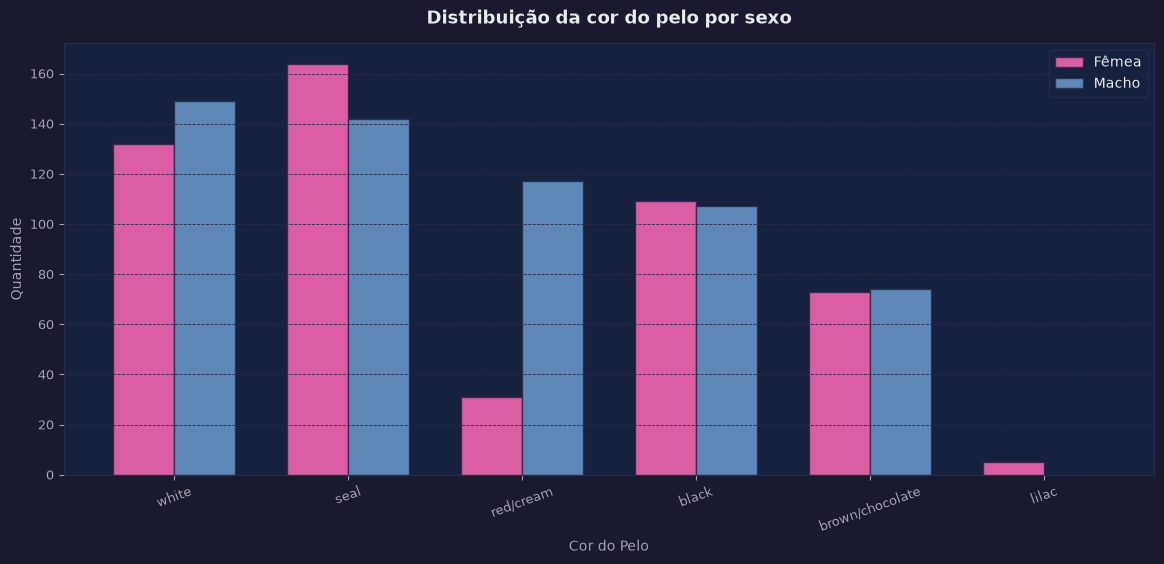

In [157]:
#Distribuição da cor do pelo por sexo
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(PALETTE['bg'])

cores_pelo = dataset['Fur_colour_dominant'].unique()
x = np.arange(len(cores_pelo))
width = 0.35

fem  = [dataset[(dataset['Fur_colour_dominant']==c) & (dataset['Gender']=='female')].shape[0] for c in cores_pelo]
masc = [dataset[(dataset['Fur_colour_dominant']==c) & (dataset['Gender']=='male')].shape[0] for c in cores_pelo]

ax.bar(x - width/2, fem,  width, label='Fêmea', color=PALETTE['gender']['female'], alpha=0.85, edgecolor='#2a2a4a')
ax.bar(x + width/2, masc, width, label='Macho', color=PALETTE['gender']['male'],   alpha=0.85, edgecolor='#2a2a4a')

ax.set_xticks(x)
ax.set_xticklabels(cores_pelo, color=PALETTE['muted'], fontsize=10, rotation=20)
ax.legend(facecolor=PALETTE['panel'], edgecolor='#2a2a4a', labelcolor=PALETTE['text'])
style_ax(ax, 'Distribuição da cor do pelo por sexo', 'Cor do Pelo', 'Quantidade')

plt.tight_layout(pad=2)
plt.show()

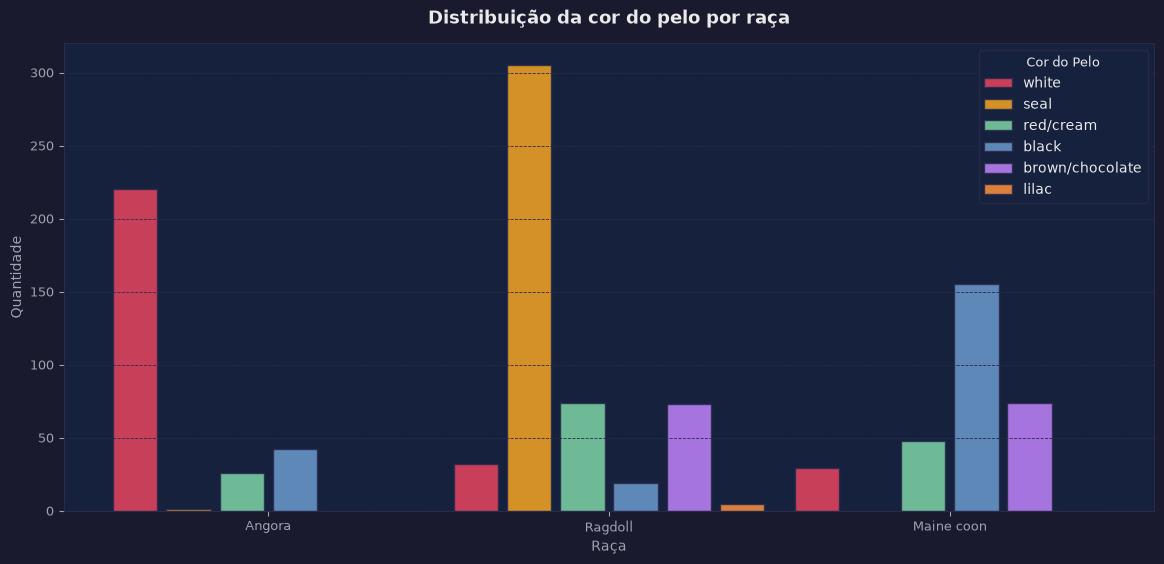

In [ ]:
#Distribuição da cor do pelo por raça
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(PALETTE['bg'])

cores_pelo = dataset['Fur_colour_dominant'].unique()
x = np.arange(len(breeds))
width = 0.13
offsets = np.linspace(-len(cores_pelo)*width/2, len(cores_pelo)*width/2, len(cores_pelo))

for cor, offset, color in zip(cores_pelo, offsets, PALETTE['cats']):
    vals = [dataset[(dataset['Breed']==b) & (dataset['Fur_colour_dominant']==cor)].shape[0] for b in breeds]
    ax.bar(x + offset, vals, width, label=cor, color=color, alpha=0.85, edgecolor='#2a2a4a')

ax.set_xticks(x)
ax.set_xticklabels(breeds, color=PALETTE['muted'], fontsize=11)
legend = ax.legend(title='Cor do Pelo', facecolor=PALETTE['panel'], edgecolor='#2a2a4a',
                   labelcolor=PALETTE['text'], title_fontsize=9)
legend.get_title().set_color(PALETTE['text'])
style_ax(ax, 'Distribuição da cor do pelo por raça', 'Raça', 'Quantidade')

plt.tight_layout(pad=2)
plt.show()

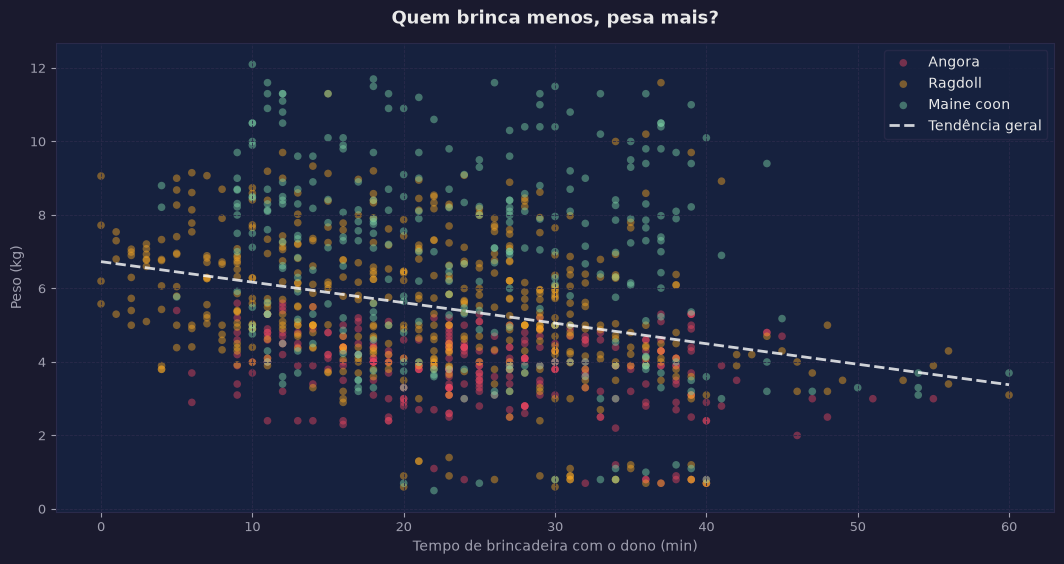

In [158]:
#Correlação entre tempo de brincadeira com o dono e peso do gato
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(PALETTE['bg'])

for breed, color in PALETTE['breeds'].items():
    sub = dataset[dataset['Breed']==breed]
    ax.scatter(sub['Owner_play_time_minutes'], sub['Weight'],
               color=color, alpha=0.45, s=30, label=breed, edgecolors='none')

m, b = np.polyfit(dataset['Owner_play_time_minutes'], dataset['Weight'], 1)
x_line = np.linspace(dataset['Owner_play_time_minutes'].min(), dataset['Owner_play_time_minutes'].max(), 100)
ax.plot(x_line, m*x_line+b, color='white', linewidth=2, linestyle='--', alpha=0.8, label='Tendência geral')

ax.legend(facecolor=PALETTE['panel'], edgecolor='#2a2a4a', labelcolor=PALETTE['text'])
style_ax(ax, 'Quem brinca menos, pesa mais?', 'Tempo de brincadeira com o dono (min)', 'Peso (kg)')
ax.grid(axis='both', color='#2a2a4a', linewidth=0.6, linestyle='--')

plt.tight_layout(pad=2)
plt.show()

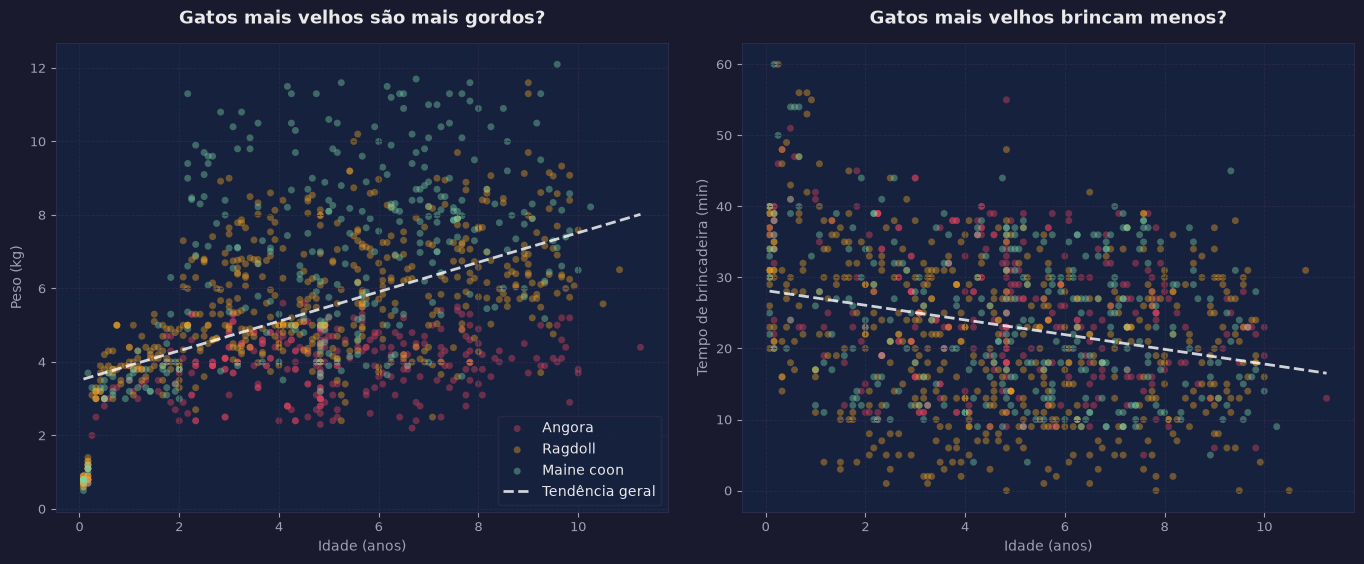

In [ ]:
#Correlação entre idade, peso e tempo de brincadeira com o dono
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(PALETTE['bg'])

for breed, color in PALETTE['breeds'].items():
    sub = dataset[dataset['Breed']==breed]
    axes[0].scatter(sub['Age_in_years'], sub['Weight'], color=color, alpha=0.4, s=25, label=breed, edgecolors='none')
    axes[1].scatter(sub['Age_in_years'], sub['Owner_play_time_minutes'], color=color, alpha=0.4, s=25, edgecolors='none')

for i, (ax, col, title, ylabel) in enumerate(zip(
    axes,
    ['Weight', 'Owner_play_time_minutes'],
    ['Gatos mais velhos são mais gordos?', 'Gatos mais velhos brincam menos?'],
    ['Peso (kg)', 'Tempo de brincadeira (min)'])):

    m, b = np.polyfit(dataset['Age_in_years'], dataset[col], 1)
    x_line = np.linspace(dataset['Age_in_years'].min(), dataset['Age_in_years'].max(), 100)
    ax.plot(x_line, m*x_line+b, color='white', linewidth=2, linestyle='--', alpha=0.8, label='Tendência geral')
    ax.set_facecolor(PALETTE['panel'])
    style_ax(ax, title, 'Idade (anos)', ylabel)
    ax.grid(axis='both', color='#2a2a4a', linewidth=0.6, linestyle='--')

axes[0].legend(facecolor=PALETTE['panel'], edgecolor='#2a2a4a', labelcolor=PALETTE['text'])

plt.tight_layout(pad=2)
plt.show()

## Insights das visualizações

**Comprimento por raça:** O Maine Coon confirmou ser a maior raça média de **58.4cm**, bem acima do Ragdoll (39.7cm) e da Angora (35.6cm), condizente com a realidade já que é uma das maiores raças domésticas do mundo.

**Raça e país predominantes:** O **Ragdoll** é a raça mais registrada (508 gatos), seguido do Maine Coon (306) e da Angora (289). Os **EUA** lideram em registros (718), seguidos por França (113), UK (110), Alemanha (88) e Canadá (74).

**Cor do pelo por sexo:** O **red/cream** é claramente mais predominante em **machos** (117 machos vs 31 fêmeas) diferença mais expressiva do dataset. O **branco** também é levemente mais comum em machos (149 vs 132). O **seal** e o **preto** têm distribuição mais equilibrada entre os sexos, com leve predominância feminina no seal (164 vs 142).

**Cor do pelo por raça:** Os resultados mostram padrões muito bem definidos:
- **Angora** → predominantemente **branco** (220 de 289 gatos)
- **Ragdoll** → predominantemente **seal** (305 de 508 gatos), o que faz total sentido pois o padrão colorpoint é característico da raça
- **Maine Coon** → maior variedade, com destaque para **preto** (155) e **brown/chocolate** (74)

**Brincadeira e peso:** Correlação negativa de **-0.26** existe uma tendência moderada de que gatos que brincam menos com o dono tendem a pesar mais, embora outros fatores como raça e idade também influenciem.

**Idade e peso:** Correlação positiva de **0.47**  a mais forte entre as analisadas. Gatos mais velhos tendem a pesar mais de forma mais consistente do que os outros fatores analisados.

**Idade e brincadeira:** Correlação negativa de **-0.26** gatos mais velhos brincam menos com o dono, o que é esperado já que filhotes e gatos jovens são naturalmente mais ativos.